# T06: Data Leakage and Chronological Split Strategy

This notebook identifies leakage risks and verifies a whole-date chronological Train/Validation/Test split for the labelled `RainTomorrow` population.

**Boundary:** the raw CSV remains unchanged. No imputation, encoding, scaling, outlier treatment, feature engineering, resampling, feature selection, model fitting, or threshold tuning is performed.

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from fdm_rainfall.data import (
    chronological_train_validation_test_split,
    load_weather_data,
    location_split_tables,
)
from fdm_rainfall.validation import (
    leakage_risk_register,
    validate_chronological_split,
    verify_weather_dataset,
)

DATASET_PATH = PROJECT_ROOT / 'data/raw/weatherAUS.csv'
TABLE_DIR = PROJECT_ROOT / 'reports/tables'
FIGURE_DIR = PROJECT_ROOT / 'reports/figures/leakage_split'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

raw_hash_before = sha256(DATASET_PATH)
weather = load_weather_data(DATASET_PATH)
print(f'Loaded raw dataset: {weather.shape[0]:,} rows x {weather.shape[1]} columns')
print(f'Raw SHA-256 before analysis: {raw_hash_before}')

Loaded raw dataset: 145,460 rows x 23 columns
Raw SHA-256 before analysis: 573fd715cd69fcacc4df32024d823b450ae3edaae7e8ff2eeb623adbed424014


## Leakage inventory and dataset structure

- **Target leakage:** `RainTomorrow` is the outcome and must not enter the future predictor matrix. `RISK_MM`, if present, would be severe leakage because it represents next-day rainfall amount and would nearly disclose the target definition.
- **Preprocessing leakage:** imputation rules, encoders, scalers, learned outlier parameters, feature selection, resampling, and later probability thresholds must be learned using training data only. These controls are planned, not implemented in T06.
- **Temporal leakage:** future observations must not influence past predictions. A random row split could place nearby dates from the same station in different subsets and expose development decisions to later-period conditions.
- **Feature-engineering leakage:** future features must use only information available on or before the observation date—never tomorrow's measurements, future rainfall, future station records, or future-inclusive aggregates.
- **Duplicate/entity leakage:** exact rows and `Date + Location` keys are checked again below. Whole calendar dates remain together across all locations.

In [2]:
verification = verify_weather_dataset(weather)
raw_dates = pd.to_datetime(weather['Date'], format='%Y-%m-%d', errors='coerce')
location_order = (
    weather.assign(_Date=raw_dates)
    .groupby('Location', sort=False)['_Date']
    .apply(lambda values: values.is_monotonic_increasing)
)
date_location_counts = weather.assign(_Date=raw_dates).groupby('_Date')['Location'].nunique()

structure_findings = pd.DataFrame({
    'Finding': [
        'Raw rows', 'Labelled RainTomorrow rows', 'Missing RainTomorrow rows',
        'Raw file globally date ordered', 'Adjacent date decreases in raw order',
        'Locations internally date ordered', 'Unique calendar dates',
        'Dates represented by multiple locations', 'Maximum locations on one date',
        'Exact duplicate rows', 'Duplicate Date + Location combinations', 'RISK_MM exists',
    ],
    'Value': [
        len(weather), verification.rain_tomorrow_labelled_count, verification.rain_tomorrow_missing_count,
        raw_dates.is_monotonic_increasing, int((raw_dates.diff() < pd.Timedelta(0)).sum()),
        f'{int(location_order.sum())} of {len(location_order)}', raw_dates.nunique(),
        int((date_location_counts > 1).sum()), int(date_location_counts.max()),
        verification.exact_duplicate_rows, verification.duplicate_date_location_combinations, verification.risk_mm_exists,
    ],
})
structure_findings

,Finding,Value
0,Raw rows,145460
1,Labelled RainTomorrow rows,142193
2,Missing RainTomorrow rows,3267
3,Raw file globally date ordered,False
4,Adjacent date decreases in raw order,48
5,Locations internally date ordered,49 of 49
6,Unique calendar dates,3436
7,Dates represented by multiple locations,3344
8,Maximum locations on one date,49
9,Exact duplicate rows,0


## Supervised population and chronological split

Only rows with a known `RainTomorrow` label are used to design the supervised split. This is an in-memory analysis view—not persisted preprocessing. Boundaries are chosen from cumulative labelled-row counts over ordered unique dates, nearest to 70% and 85% of the population. Exact percentages are not forced because a date is never divided across subsets.

In [3]:
labelled_population = int(weather['RainTomorrow'].notna().sum())
split = chronological_train_validation_test_split(
    weather,
    date_column='Date',
    target_column='RainTomorrow',
    require_non_missing_target=True,
    train_fraction=0.70,
    validation_fraction=0.15,
)
split_summary = split.summary.copy()
split_target_distribution = split_summary[[
    'Split', 'Rows', 'RainTomorrow No count', 'RainTomorrow Yes count',
    'Yes percentage', 'Missing target count',
]].copy()
split_summary.to_csv(TABLE_DIR / '06_split_summary.csv', index=False)
split_target_distribution.to_csv(TABLE_DIR / '06_split_target_distribution.csv', index=False)
print(f'Raw population: {len(weather):,}; labelled analysis population: {labelled_population:,}')
split_summary

Raw population: 145,460; labelled analysis population: 142,193


,Split,First date,Last date,Rows,Percentage of labelled rows,Unique dates,Locations,RainTomorrow No count,RainTomorrow Yes count,Yes percentage,Missing target count
0,Train,2007-11-01,2015-01-12,99546,70.007666,2541,49,77087,22459,22.561429,0
1,Validation,2015-01-13,2016-04-08,21342,15.009178,452,48,16990,4352,20.391716,0
2,Test,2016-04-09,2017-06-25,21305,14.983157,443,49,16239,5066,23.778456,0


## Location coverage

Coverage differences are retained and documented. They matter because evaluation periods may represent a different station mix, and station-specific gaps can make temporal performance less directly comparable. No location is dropped.

In [4]:
location_coverage, location_counts = location_split_tables(split)
location_coverage.to_csv(TABLE_DIR / '06_location_split_coverage.csv', index=False)
location_counts.to_csv(TABLE_DIR / '06_location_split_counts.csv', index=False)

locations_all_three = location_coverage.loc[location_coverage['Present in all three'], 'Location'].tolist()
absent_validation = location_coverage.loc[~location_coverage['Present in Validation'], 'Location'].tolist()
absent_test = location_coverage.loc[~location_coverage['Present in Test'], 'Location'].tolist()
begin_late = location_coverage.loc[location_coverage['Begins after labelled population starts'], 'Location'].tolist()
end_early = location_coverage.loc[location_coverage['Ends before labelled population ends'], 'Location'].tolist()
print(f'Locations in all three splits: {len(locations_all_three)}')
print(f'Absent from Validation: {absent_validation or ["None"]}')
print(f'Absent from Test: {absent_test or ["None"]}')
print(f'Begin after overall labelled start: {len(begin_late)} locations')
print(f'End before overall labelled end: {len(end_early)} locations: {end_early}')
location_counts

Locations in all three splits: 48
Absent from Validation: ['Melbourne']
Absent from Test: ['None']
Begin after overall labelled start: 48 locations
End before overall labelled end: 9 locations: ['Adelaide', 'AliceSprings', 'Darwin', 'Katherine', 'MountGambier', 'Newcastle', 'Nuriootpa', 'Uluru', 'Woomera']


,Location,Train,Validation,Test
0,Adelaide,2203,447,440
1,Albany,2137,450,429
2,Albury,2121,452,438
3,AliceSprings,2145,452,434
4,BadgerysCreek,2057,446,425
5,Ballarat,2135,450,443
6,Bendigo,2145,450,439
7,Brisbane,2281,442,438
8,Cairns,2141,452,395
9,Canberra,2529,448,441


## Automated split validation and leakage controls

Controls marked **Implemented now** are limited to date-safe splitting, validation, and leakage identification. Controls marked **Planned**—including train-only imputation, encoding, scaling, feature selection, class balancing, and probability-threshold fitting—belong to T07 or later.

In [5]:
split_validation = validate_chronological_split(
    split.train, split.validation, split.test,
    labelled_population_size=labelled_population,
)
risk_register = leakage_risk_register()
split_validation.to_csv(TABLE_DIR / '06_split_validation.csv', index=False)
risk_register.to_csv(TABLE_DIR / '06_leakage_risk_register.csv', index=False)
print(split_validation.to_string(index=False))
print(f'\nAll split validations pass: {(split_validation["Result"] == "PASS").all()}')
risk_register

                                                  Check Result                                                                   Details
               Train, validation and test are non-empty   PASS                                 Train=99546, Validation=21342, Test=21305
                         Date values parse successfully   PASS                All split dates must be valid before temporal comparisons.
                            No source-row index overlap   PASS              Each labelled source index must occur in exactly one subset.
                               No calendar-date overlap   PASS                   A calendar date must not occur in more than one subset.
          Chronological boundaries are strictly ordered   PASS             max(Train) < min(Validation) and max(Validation) < min(Test).
                   Split rows equal labelled population   PASS                            Split rows=142193; labelled population=142193.
                     RainTomorrow exists 

,Risk,Example in this project,Potential consequence,Control / prevention,Stage where controlled,Status
0,Target leakage,RainTomorrow included among predictors,The model would be given the answer it is mean...,Explicitly exclude RainTomorrow from the futur...,T07/later,Planned
1,RISK_MM leakage,RISK_MM contains next-day rainfall amount,Near-direct target disclosure would produce un...,Verify RISK_MM is absent and reject it if enco...,T01 and T06,Implemented now
2,Imputation leakage,"Means, medians, modes, or categorical rules le...",Validation/test information would influence tr...,Fit numerical and categorical imputation rules...,T07,Planned
3,Encoding leakage,Categories or encoders learned from validation...,Future category information would shape the tr...,Fit encoders on Train only; define unknown-cat...,T07,Planned
4,Scaling leakage,Scaling statistics calculated across all three...,Future distributions would influence transform...,Fit scalers on Train only and apply unchanged ...,T07,Planned
5,Feature-selection leakage,Selecting predictors using validation/test out...,Reported performance would be optimistically b...,Select features within Train/development proce...,T07/later,Planned
6,Resampling leakage,Class balancing before the split or across val...,Synthetic or duplicated information could cros...,Apply any class balancing to Train only after ...,Later modelling,Planned
7,Temporal leakage,Random rows place later weather in development...,Evaluation would not represent prediction on u...,Use whole-date chronological Train/Validation/...,T06,Implemented now
8,Future-derived feature leakage,"Tomorrow's measurements, future rainfall/stati...",Predictors would contain information unavailab...,Require every engineered feature to use observ...,T08,Planned
9,Test-set reuse / tuning leakage,Repeatedly choosing models or probability thre...,The Test set would cease to represent an indep...,Fit thresholds within a training-only developm...,Later modelling,Planned


## Focused visual checks

The timeline makes the strict temporal boundaries visible. The Yes-rate comparison documents distribution shift without rebalancing or modelling.

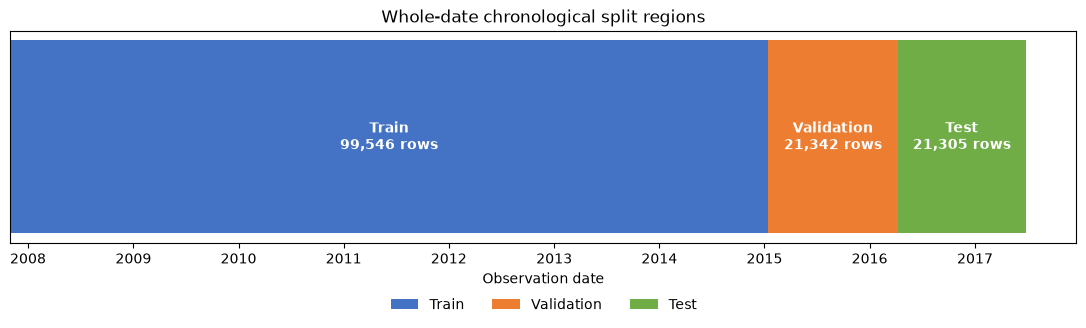

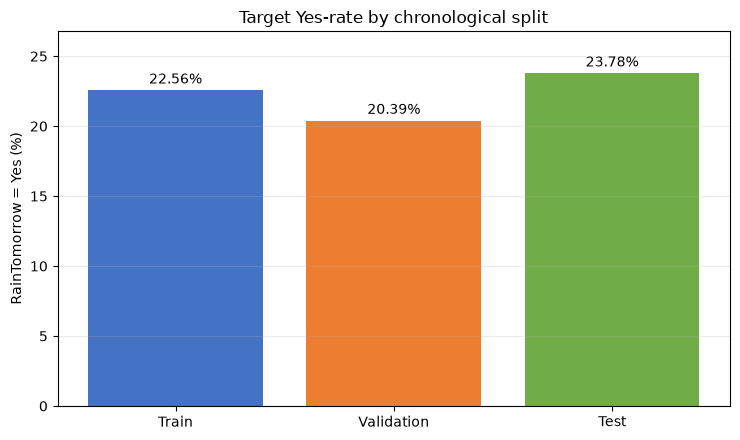

In [6]:
plot_summary = split_summary.copy()
plot_summary['First date'] = pd.to_datetime(plot_summary['First date'])
plot_summary['Last date'] = pd.to_datetime(plot_summary['Last date'])
colors = ['#4472C4', '#ED7D31', '#70AD47']

fig, ax = plt.subplots(figsize=(11, 3.5))
for row, color in zip(plot_summary.itertuples(index=False), colors):
    start = mdates.date2num(row._1)
    end = mdates.date2num(row._2)
    ax.barh(0, end - start + 1, left=start, height=0.5, color=color, label=row.Split)
    ax.text((start + end) / 2, 0, f'{row.Split}\n{row.Rows:,} rows', ha='center', va='center', color='white', fontweight='bold')
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_yticks([])
ax.set_xlabel('Observation date')
ax.set_title('Whole-date chronological split regions')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '06_chronological_split_timeline.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(split_summary['Split'], split_summary['Yes percentage'], color=colors)
for bar, value in zip(bars, split_summary['Yes percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.25, f'{value:.2f}%', ha='center', va='bottom')
ax.set_ylabel('RainTomorrow = Yes (%)')
ax.set_title('Target Yes-rate by chronological split')
ax.set_ylim(0, max(split_summary['Yes percentage']) + 3)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '06_split_target_yes_rate.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## Interpretation and limitations

The raw file is grouped by location rather than globally sorted: each of the 49 locations is internally chronological, but the combined row sequence has date resets and extensive cross-location date overlap. A random row split would therefore mix historical and future periods and commonly place nearby station-days in different subsets. The chronological strategy better simulates evaluation on unseen future days.

The split also exposes genuine distribution shift: target Yes-rates and station coverage vary by period. Melbourne has no labelled observations in Validation because its labelled series has a long gap spanning that interval, but it is retained in Train and Test. Chronological splitting does not eliminate spatial dependence, serial dependence within each subset, climate drift, station-coverage changes, or leakage from incorrectly designed future features. Those remain limitations and controls for later stages.

In [7]:
raw_hash_after = sha256(DATASET_PATH)
assert raw_hash_after == raw_hash_before
assert (split_validation['Result'] == 'PASS').all()
print(f'Raw SHA-256 after analysis:  {raw_hash_after}')
print('Raw dataset unchanged: True')
print('T06 scope respected: no preprocessing, feature engineering, resampling, or modelling performed.')

Raw SHA-256 after analysis:  573fd715cd69fcacc4df32024d823b450ae3edaae7e8ff2eeb623adbed424014
Raw dataset unchanged: True
T06 scope respected: no preprocessing, feature engineering, resampling, or modelling performed.
